# PRAGMA Phase 8 - Durable distributed pretraining

Builds `PretrainingEngine` (section 13.1, 11.4; ADR 0011): the dynamic `TokenBudgetBatchSampler`, `OptimizerFactory` (AdamW / hybrid Muon+AdamW), `SchedulerFactory`, and `CheckpointManager` wired into one Accelerate-based train loop, plus `evaluate()` for a real validation-loss curve.

**Hardware auto-detection, not a config flag.** This notebook never chooses a device or decides whether to use DDP — that is entirely `Accelerate`'s job. Running this notebook directly gives single-device execution (CPU here, since this machine's GPU driver is too old for current CUDA wheels — `CLAUDE.md`'s environment note); launching the equivalent script via `accelerate launch --multi_gpu --num_processes=N` would give DDP across N GPUs with *zero* code changes. `CFG.DEBUG` below only controls how tiny the run is, matching the smoke-test pattern from `007_debug_training.ipynb` — not device selection.

Checks the Phase 8 exit gate on the single-device case this machine can actually run: **a stopped run resumes correctly** (exact loss-trajectory match, not just "doesn't crash") and **throughput/token-count/masking metrics are trustworthy**. Real multi-GPU comparability could not be tested here (ADR 0011) and needs re-verification once GPU hardware is available.

**All metrics here are logged to MLflow, not just printed** — the plots below are built by reading them back (`MlflowClient().get_metric_history`), and the last section shows exactly how to open the full MLflow UI on this run afterward.

In [1]:
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from mlflow.tracking import MlflowClient

from pragma.config import MaskingConfig, TokenBudgetConfig, TrainingConfig
from pragma.data import ParquetShardStore, TokenizedRecordDataset
from pragma.modeling import PragmaConfig
from pragma.processing import PragmaProcessor
from pragma.schema import SchemaRegistry
from pragma.training import PretrainingEngine, resolve_mixed_precision

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

2026/09/06 19:08:45 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at C:\Users\levyr\Desktop\random-projects\pragma\.venv\Lib\site-packages\mlflow\assistant\skills\instrumenting-with-mlflow-tracing\SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


## What will `Accelerate` actually pick?

This is the whole point of ADR 0011: nothing in `pragma.training` asks this question except to resolve mixed-precision support — device/process-count selection is entirely `Accelerate`'s job. `resolve_mixed_precision` is a pure function (no `Accelerator` instantiation), so it's safe to call before building anything.

**A note on `Accelerator` itself**: it holds *process-wide* singleton state — the first `Accelerator(...)` call in a process fixes `mixed_precision` for every later call in that same process (confirmed directly: a second call requesting a different value raises). One real training script only ever builds one `PretrainingEngine`, so this never comes up in practice; this notebook builds several engines back-to-back to demonstrate resume, so every `TrainingConfig` below intentionally requests the same `mixed_precision`.

In [2]:
print(f"cuda available: {torch.cuda.is_available()}")
print(f"requested bf16 resolves to: {resolve_mixed_precision('bf16')!r}")
print(f"requested fp16 resolves to: {resolve_mixed_precision('fp16')!r}")

cuda available: False
requested bf16 resolves to: 'bf16'
requested fp16 resolves to: 'no'


## `CFG.DEBUG`: a small fraction of data, a small model

Same knob as `007_debug_training.ipynb` — this is a correctness smoke test of the *engine*, not a throughput run.

In [3]:
@dataclass(frozen=True)
class CFG:
    DEBUG: bool = True

    n_train_records: int = 24 if DEBUG else None  # None = use the full train split
    n_val_records: int = 8 if DEBUG else None
    hidden_size: int = 16 if DEBUG else 192
    num_heads: int = 2 if DEBUG else 3
    intermediate_size: int = 32 if DEBUG else 768
    event_layers: int = 2 if DEBUG else 5
    history_layers: int = 1 if DEBUG else 2

    n_epochs: int = 4
    checkpoint_every_n_steps: int = 3
    max_event_tokens_per_batch: int = 300 if DEBUG else 4096
    max_events_per_batch: int = 200 if DEBUG else 2048
    max_records_per_batch: int = 8 if DEBUG else 256


cfg = CFG()
cfg

CFG(DEBUG=True, n_train_records=24, n_val_records=8, hidden_size=16, num_heads=2, intermediate_size=32, event_layers=2, history_layers=1, n_epochs=4, checkpoint_every_n_steps=3, max_event_tokens_per_batch=300, max_events_per_batch=200, max_records_per_batch=8)

## Load the fitted processor and small train/validation slices

In [4]:
registry = SchemaRegistry.default()
processor = PragmaProcessor.load(REPO_ROOT / "data" / "processor", registry)

full_train_dataset = TokenizedRecordDataset.from_store(
    REPO_ROOT / "data" / "shards", ParquetShardStore(), split="train"
)
full_val_dataset = TokenizedRecordDataset.from_store(
    REPO_ROOT / "data" / "shards", ParquetShardStore(), split="val"
)

train_records = [r for r in full_train_dataset._records if r.events]
val_records = [r for r in full_val_dataset._records if r.events]
if cfg.n_train_records is not None:
    train_records = train_records[: cfg.n_train_records]
if cfg.n_val_records is not None:
    val_records = val_records[: cfg.n_val_records]

train_dataset = TokenizedRecordDataset(train_records)
val_dataset = TokenizedRecordDataset(val_records)
print(f"{len(train_dataset)} train records, {len(val_dataset)} val records, "
      f"vocab_size={processor.total_vocab_size}")

24 train records, 8 val records, vocab_size=412


## `TokenBudgetBatchSampler` diagnostics

Section 9.3's reporting requirement: actual tokens/events/records and the batch-size distribution the dynamic sampler actually produced.

In [5]:
from pragma.data import TokenBudgetBatchSampler

token_budget_config = TokenBudgetConfig(
    max_event_tokens_per_batch=cfg.max_event_tokens_per_batch,
    max_events_per_batch=cfg.max_events_per_batch,
    max_records_per_batch=cfg.max_records_per_batch,
)
probe_sampler = TokenBudgetBatchSampler(train_dataset, token_budget_config)
stats = probe_sampler.stats()
print(f"n_batches: {stats.n_batches}")
print(f"n_records: {stats.n_records}, n_events: {stats.n_events}, n_event_tokens: {stats.n_event_tokens}")
print(f"mean records/batch: {stats.mean_records_per_batch:.2f}")
print(f"mean event tokens/batch: {stats.mean_event_tokens_per_batch:.1f}")

n_batches: 13
n_records: 24, n_events: 559, n_event_tokens: 2927
mean records/batch: 1.85
mean event tokens/batch: 225.2


## Build the engine and train, tracking validation loss too

MLflow's tracking store lives at `data/mlflow/mlflow.db` — persistent across notebook re-runs (unlike the checkpoint directory, cleaned up at the end below) so you can still open the MLflow UI on it afterward.

In [6]:
pragma_config = PragmaConfig.from_processor(
    processor,
    hidden_size=cfg.hidden_size,
    num_heads=cfg.num_heads,
    intermediate_size=cfg.intermediate_size,
    profile_layers=1,
    event_layers=cfg.event_layers,
    history_layers=cfg.history_layers,
)
masking_config = MaskingConfig()

checkpoint_dir = REPO_ROOT / "data" / "_notebook_checkpoints"
mlflow_db = REPO_ROOT / "data" / "mlflow" / "mlflow.db"
mlflow_db.parent.mkdir(parents=True, exist_ok=True)
training_config = TrainingConfig(
    n_epochs=cfg.n_epochs,
    mixed_precision="bf16",  # resolved automatically per the hardware probe above
    checkpoint_dir=str(checkpoint_dir),
    checkpoint_every_n_steps=cfg.checkpoint_every_n_steps,
    log_every_n_steps=1,
    mlflow_tracking_uri=f"sqlite:///{mlflow_db}",
    seed=123,
)

engine = PretrainingEngine(
    train_dataset,
    processor,
    pragma_config,
    masking_config,
    training_config,
    token_budget_config,
    processor_dir=REPO_ROOT / "data" / "processor",
)
print(f"device: {engine.accelerator.device}")
print(f"num_processes: {engine.accelerator.num_processes}")
print(f"process_index: {engine.accelerator.process_index}")
print(f"mlflow run_id: {engine.mlflow_run_id}")

history = engine.train(end_epoch=2, val_dataset=val_dataset)
for m in history:
    print(m)
print("counters after 2 epochs:", engine.counters)

2026/09/06 19:09:00 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/09/06 19:09:00 INFO mlflow.store.db.utils: Updating database tables


2026/09/06 19:09:02 INFO mlflow.tracking.fluent: Experiment with name 'pragma-pretraining' does not exist. Creating a new experiment.


device: cpu
num_processes: 1
process_index: 0
mlflow run_id: 3de33b1044544215a3d3b4acb2f95a66


[RANK 0] Removed shared tensor {'pragma.profile_encoder.embedding.embedding.weight', 'pragma.event_encoder.embedding.embedding.weight', 'mlm_head.embedding.embedding.weight'} while saving. This should be OK, but check by verifying that you don't receive any warning while reloading


...

[RANK 0] Removed shared tensor {'pragma.profile_encoder.embedding.embedding.weight', 'pragma.event_encoder.embedding.embedding.weight', 'mlm_head.embedding.embedding.weight'} while saving. This should be OK, but check by verifying that you don't receive any warning while reloading


[RANK 0] Removed shared tensor {'pragma.profile_encoder.embedding.embedding.weight', 'pragma.event_encoder.embedding.embedding.weight', 'mlm_head.embedding.embedding.weight'} while saving. This should be OK, but check by verifying that you don't receive any warning while reloading


[RANK 0] Removed shared tensor {'pragma.profile_encoder.embedding.embedding.weight', 'pragma.event_encoder.embedding.embedding.weight', 'mlm_head.embedding.embedding.weight'} while saving. This should be OK, but check by verifying that you don't receive any warning while reloading


[RANK 0] Removed shared tensor {'pragma.profile_encoder.embedding.embedding.weight', 'pragma.event_encoder.embedding.embedding.weight', 'mlm_head.embedding.embedding.weight'} while saving. This should be OK, but check by verifying that you don't receive any warning while reloading


EpochMetrics(epoch=0, mean_loss=5.949420635516827, n_steps=13, n_records=24, n_events=559, n_event_tokens=2927, seconds=1.375781900016591, val_loss=5.944648265838623)
EpochMetrics(epoch=1, mean_loss=5.935058457510812, n_steps=14, n_records=24, n_events=559, n_event_tokens=2927, seconds=1.3519409999717027, val_loss=5.92582893371582)
counters after 2 epochs: TrainingCounters(global_step=27, tokens_processed=5854, events_processed=1118, records_processed=48, epoch=2)


## Plot: per-step train loss and learning rate, read back from MLflow

Nothing here is stored separately for plotting — `MlflowClient.get_metric_history` reads back exactly what `PretrainingEngine` already logged during training.

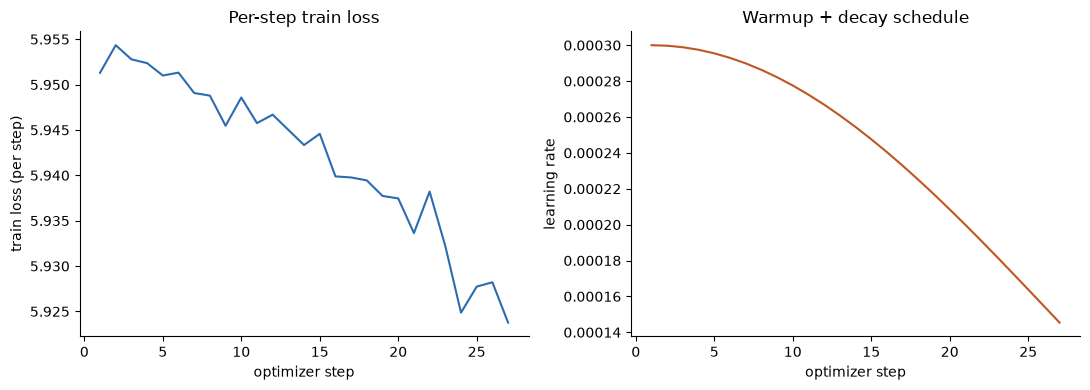

In [7]:
def metric_history(client, run_id, key):
    points = client.get_metric_history(run_id, key)
    points.sort(key=lambda p: p.step)
    return [p.step for p in points], [p.value for p in points]


client = MlflowClient()
steps, losses = metric_history(client, engine.mlflow_run_id, "loss")
_, lrs = metric_history(client, engine.mlflow_run_id, "lr")

fig, (ax_loss, ax_lr) = plt.subplots(1, 2, figsize=(11, 4))
ax_loss.plot(steps, losses, color="#2b6cb0", linewidth=1.5)
ax_loss.set_xlabel("optimizer step")
ax_loss.set_ylabel("train loss (per step)")
ax_loss.set_title("Per-step train loss")
ax_loss.spines[["top", "right"]].set_visible(False)

ax_lr.plot(steps, lrs, color="#c05621", linewidth=1.5)
ax_lr.set_xlabel("optimizer step")
ax_lr.set_ylabel("learning rate")
ax_lr.set_title("Warmup + decay schedule")
ax_lr.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

## Plot: per-epoch train vs. validation loss

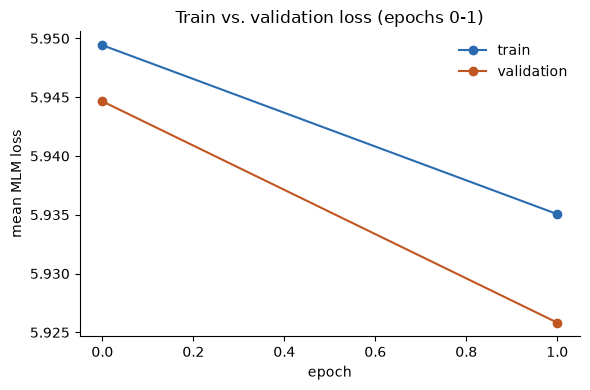

In [8]:
epoch_steps, epoch_train = metric_history(client, engine.mlflow_run_id, "epoch_mean_loss")
_, epoch_val = metric_history(client, engine.mlflow_run_id, "epoch_val_loss")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(epoch_steps, epoch_train, marker="o", color="#2b6cb0", label="train")
ax.plot(epoch_steps, epoch_val, marker="o", color="#c05621", label="validation")
ax.set_xlabel("epoch")
ax.set_ylabel("mean MLM loss")
ax.set_title("Train vs. validation loss (epochs 0-1)")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()

## Exit gate: a stopped run resumes correctly

Save a checkpoint here (simulating an interruption after epoch 2 of 4), then build a **completely fresh** engine and resume from it — the restored counters and the continued training must pick up exactly where the original engine left off. This is a *new* MLflow run (a real resumed job would be a new process too), so we'll stitch its metric history onto the first run's afterward.

In [9]:
checkpoint_path = engine.save_checkpoint("epoch_2")
print(f"checkpoint written to {checkpoint_path}")
first_run_id = engine.mlflow_run_id
engine.close()

[RANK 0] Removed shared tensor {'pragma.profile_encoder.embedding.embedding.weight', 'pragma.event_encoder.embedding.embedding.weight', 'mlm_head.embedding.embedding.weight'} while saving. This should be OK, but check by verifying that you don't receive any warning while reloading


checkpoint written to C:\Users\levyr\Desktop\random-projects\pragma\data\_notebook_checkpoints\epoch_2


In [10]:
resumed_engine = PretrainingEngine(
    train_dataset,
    processor,
    pragma_config,
    masking_config,
    training_config,
    token_budget_config,
    processor_dir=REPO_ROOT / "data" / "processor",
)
resumed_engine.resume("epoch_2")
print(f"resumed at counters: {resumed_engine.counters}")
assert resumed_engine.counters.epoch == 2
assert resumed_engine.counters.global_step == engine.counters.global_step

rest_of_history = resumed_engine.train(
    start_epoch=resumed_engine.counters.epoch, val_dataset=val_dataset
)
for m in rest_of_history:
    print(m)
second_run_id = resumed_engine.mlflow_run_id
resumed_engine.close()

resumed at counters: TrainingCounters(global_step=27, tokens_processed=5854, events_processed=1118, records_processed=48, epoch=2)


[RANK 0] Removed shared tensor {'pragma.profile_encoder.embedding.embedding.weight', 'pragma.event_encoder.embedding.embedding.weight', 'mlm_head.embedding.embedding.weight'} while saving. This should be OK, but check by verifying that you don't receive any warning while reloading


[RANK 0] Removed shared tensor {'pragma.profile_encoder.embedding.embedding.weight', 'pragma.event_encoder.embedding.embedding.weight', 'mlm_head.embedding.embedding.weight'} while saving. This should be OK, but check by verifying that you don't receive any warning while reloading


[RANK 0] Removed shared tensor {'pragma.profile_encoder.embedding.embedding.weight', 'pragma.event_encoder.embedding.embedding.weight', 'mlm_head.embedding.embedding.weight'} while saving. This should be OK, but check by verifying that you don't receive any warning while reloading


[RANK 0] Removed shared tensor {'pragma.profile_encoder.embedding.embedding.weight', 'pragma.event_encoder.embedding.embedding.weight', 'mlm_head.embedding.embedding.weight'} while saving. This should be OK, but check by verifying that you don't receive any warning while reloading


...

[RANK 0] Removed shared tensor {'pragma.profile_encoder.embedding.embedding.weight', 'pragma.event_encoder.embedding.embedding.weight', 'mlm_head.embedding.embedding.weight'} while saving. This should be OK, but check by verifying that you don't receive any warning while reloading


[RANK 0] Removed shared tensor {'pragma.profile_encoder.embedding.embedding.weight', 'pragma.event_encoder.embedding.embedding.weight', 'mlm_head.embedding.embedding.weight'} while saving. This should be OK, but check by verifying that you don't receive any warning while reloading


[RANK 0] Removed shared tensor {'pragma.profile_encoder.embedding.embedding.weight', 'pragma.event_encoder.embedding.embedding.weight', 'mlm_head.embedding.embedding.weight'} while saving. This should be OK, but check by verifying that you don't receive any warning while reloading


[RANK 0] Removed shared tensor {'pragma.profile_encoder.embedding.embedding.weight', 'pragma.event_encoder.embedding.embedding.weight', 'mlm_head.embedding.embedding.weight'} while saving. This should be OK, but check by verifying that you don't receive any warning while reloading


EpochMetrics(epoch=2, mean_loss=5.9168625218527655, n_steps=14, n_records=24, n_events=559, n_event_tokens=2927, seconds=1.4870392000302672, val_loss=5.911048412322998)
EpochMetrics(epoch=3, mean_loss=5.905055556978498, n_steps=14, n_records=24, n_events=559, n_event_tokens=2927, seconds=1.5063604998867959, val_loss=5.909022808074951)


## Plot: the *whole* run, stitched across the resume boundary

`global_step` keeps counting up across the resume (it's part of `TrainingCounters`, restored from the checkpoint), so the two runs' per-step metrics concatenate into one continuous curve with no overlap or gap — exactly what actually happened, across a process restart.

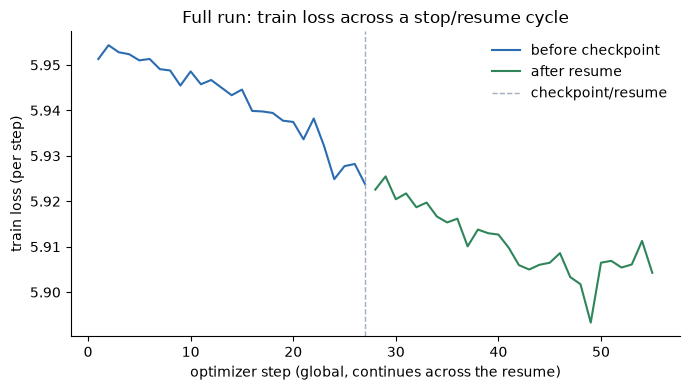

In [11]:
steps_1, losses_1 = metric_history(client, first_run_id, "loss")
steps_2, losses_2 = metric_history(client, second_run_id, "loss")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(steps_1, losses_1, color="#2b6cb0", linewidth=1.5, label="before checkpoint")
ax.plot(steps_2, losses_2, color="#2f855a", linewidth=1.5, label="after resume")
ax.axvline(steps_1[-1], color="#a0aec0", linestyle="--", linewidth=1, label="checkpoint/resume")
ax.set_xlabel("optimizer step (global, continues across the resume)")
ax.set_ylabel("train loss (per step)")
ax.set_title("Full run: train loss across a stop/resume cycle")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()

## Exit gate: checkpoint fails loudly without its matching processor

Per ADR 0007, a checkpoint is invalid without the exact processor bundle that produced its token IDs — corrupt the bundle and confirm `resume` refuses to proceed silently.

In [12]:
import shutil

backup_bundle = (REPO_ROOT / "data" / "processor" / "bundle.json").read_text()
(REPO_ROOT / "data" / "processor" / "bundle.json").write_text('{"corrupted": true}')

mismatch_engine = PretrainingEngine(
    train_dataset,
    processor,
    pragma_config,
    masking_config,
    training_config,
    token_budget_config,
    processor_dir=REPO_ROOT / "data" / "processor",
)
try:
    mismatch_engine.resume("epoch_2")
    raised = False
except ValueError as exc:
    raised = True
    print(f"correctly refused to resume: {exc}")
finally:
    mismatch_engine.close()
    (REPO_ROOT / "data" / "processor" / "bundle.json").write_text(backup_bundle)

assert raised

correctly refused to resume: processor bundle at C:\Users\levyr\Desktop\random-projects\pragma\data\processor does not match this checkpoint (expected hash 8e43c1d03d07955e545c5aca500c9d31e518ed1ed2539bc884ee11e848ea06e4, got 952a1a3df5bf139a4a7f5b4f55721f9da6c09d684093d063b96f63911fd6576c) — a checkpoint is invalid without its exact matching processor bundle (ADR 0007)


## Where to see the full MLflow report

Everything plotted above (and more — parameters, artifacts, run comparisons) is in the tracking store this notebook wrote to:

```bash
mlflow ui --backend-store-uri sqlite:///data/mlflow/mlflow.db
```

then open **http://127.0.0.1:5000** in a browser, pick the `pragma-pretraining` experiment, and open either run from this notebook (or select both and click **Compare** to see them side by side, including the LR/loss charts the UI builds automatically from the same logged metrics). This file persists across notebook re-runs (it's gitignored, not deleted by the cleanup cell below) — every past run stays in it unless you delete `data/mlflow/`.

You don't need the UI running to query metrics programmatically either — that's exactly what `MlflowClient().get_metric_history` did for the plots above, and `mlflow.search_runs()` lists every run's final metrics as a DataFrame if you want a quick table instead of the full UI.

In [13]:
import mlflow

mlflow.set_tracking_uri(f"sqlite:///{mlflow_db}")
runs_df = mlflow.search_runs(experiment_names=["pragma-pretraining"])
runs_df[["run_id", "status", "metrics.epoch_mean_loss", "metrics.epoch_val_loss"]].head()

,run_id,status,metrics.epoch_mean_loss,metrics.epoch_val_loss
0,54bcac2d50614fb2b067dfdb8b2a0e8b,FINISHED,NaN,NaN
1,aa48eb0025e64f4ea50a548d8d0f98c2,FINISHED,5.905056,5.909023
2,3de33b1044544215a3d3b4acb2f95a66,FINISHED,5.935058,5.925829


## Cleanup

Remove this notebook's scratch **checkpoints** only — `data/mlflow/mlflow.db` is left in place so the instructions above keep working after this notebook finishes.

In [14]:
shutil.rmtree(checkpoint_dir, ignore_errors=True)
print("cleaned up", checkpoint_dir)
print("kept for later inspection:", mlflow_db)

cleaned up C:\Users\levyr\Desktop\random-projects\pragma\data\_notebook_checkpoints
kept for later inspection: C:\Users\levyr\Desktop\random-projects\pragma\data\mlflow\mlflow.db


## Reference: how this would actually launch on multiple GPUs

Nothing above changes. From a shell, instead of running this notebook/script directly:

```bash
accelerate config  # one-time interactive setup, or write a YAML by hand
accelerate launch --multi_gpu --num_processes=4 scripts/pretrain.py
```

`Accelerator()` inside `PretrainingEngine` detects it is running under `accelerate launch` with 4 processes and wraps the model in `DistributedDataParallel` automatically; `TokenBudgetBatchSampler` already takes `num_replicas`/`rank` from `accelerator.num_processes`/`process_index`, so each rank gets a balanced, disjoint slice of batches with no further changes (ADR 0011). `scripts/pretrain.py` now exists (added in Phase 9, once a real pilot run needed one) - a thin wrapper the same shape as `scripts/fit_processor.py` around exactly this `PretrainingEngine`, exercised end to end in `010_pilot_pretraining.ipynb`.